# MOVE ON – HUR knee isometric analysis

This notebook is a template for reading HUR knee isometric data, calculating corrected peak torque values, comparing the results to reference values, and presenting the main interpretation outputs.

Use the same notebook for all HUR cases by changing only
1. **casefile**
2. **parameters** according to patient profile

In [215]:
# @title 1) Hidden setup (do not edit)

UTILS_CODE = r'''
"""
Utility functions for the MOVE ON HUR teaching notebook.
Embedded directly inside the notebook for a self-contained Colab workflow.
"""

import re
import urllib.request
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# --- Plot style ---
sns.set_theme(style="white")
plt.rcParams["axes.grid"] = False

# --- GitHub data source handling ---
GITHUB_USER = "tuxotiikeri"
GITHUB_REPO = "MoveOn"
GITHUB_BRANCH = "main"

BASE_RAW_URL = f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/data"

CASE_FILES = {
    "ACL": "acl_hur_measurement.xls",
    "Hamstrings": "hamstrings_hur_measurement.xls",
    "Knee OA": "knee_oa_hur_measurement.xls",
    "Menisci": "menisci_hur_measurement.xls",
    "Example": "example_hur_measurement.xls"
}

REFERENCE_FILE = "isometric_reference_values_tidy.csv"

REFERENCE_PATHS = [
    Path(REFERENCE_FILE),
]

REFERENCE_SOURCE_TEXT = (
    "Reference source: Sarabon et al. Frontiers in Physiology (2021), "
    "Table 1. Manual check: https://pmc.ncbi.nlm.nih.gov/articles/instance/8554160/bin/Table_1.pdf"
)

# --- Movement name translation ---
REPL = {
    "Vasen Ojennus": "Left Extension",
    "Vasen Koukistus": "Left Flexion",
    "Oikea Ojennus": "Right Extension",
    "Oikea Koukistus": "Right Flexion",
}

_GROUP_MAP = {
    "athletic": "athletes",
    "athlete": "athletes",
    "athletes": "athletes",
    "adult": "adults",
    "adults": "adults",
    "elder": "elderly",
    "elderly": "elderly",
}
_GENDER_MAP = {
    "male": "male",
    "female": "female",
    "both": "both",
}
_TASK_TO_ANGLE = {
    "extension": "mid-range",
    "flexion": "extended",
}


# =========================================================
# Basic helpers
# =========================================================

def _to_float(x):
    if x is None:
        return np.nan
    s = str(x).strip()
    if s in ("", "-"):
        return np.nan
    s = s.replace(",", ".").replace("%", "")
    try:
        return float(s)
    except ValueError:
        return np.nan


def _parse_reference_numeric(series):
    return (
        series.astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )


def parse_movement(name: str):
    s = (name or "").strip().lower()
    limb = "left" if s.startswith("left") else ("right" if s.startswith("right") else None)

    if "extension" in s or "ojenn" in s:
        direction = "extension"
    elif "flex" in s or "kouk" in s:
        direction = "flexion"
    else:
        direction = None

    return limb, direction


def _normalise_group(group: str) -> str:
    return _GROUP_MAP.get(str(group).strip().lower(), "adults")


def _normalise_gender(gender: str) -> str:
    return _GENDER_MAP.get(str(gender).strip().lower(), "female")


def _title_gender(gender_key: str) -> str:
    return {"male": "Male", "female": "Female", "both": "Both"}.get(gender_key, str(gender_key).title())


def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


# =========================================================
# GitHub download helpers
# =========================================================

def download_from_github(filename, destination=None, base_url=BASE_RAW_URL):
    if destination is None:
        destination = filename

    url = f"{base_url}/{filename}"
    try:
        urllib.request.urlretrieve(url, destination)
    except Exception as e:
        raise RuntimeError(f"Could not download file from {url}") from e

    return destination


def download_case_and_reference(case_label):
    if case_label not in CASE_FILES:
        raise ValueError(f"Unknown case: {case_label}. Options: {list(CASE_FILES.keys())}")

    case_filename = CASE_FILES[case_label]
    case_local_path = download_from_github(case_filename, destination=case_filename)
    ref_local_path = download_from_github(REFERENCE_FILE, destination=REFERENCE_FILE)
    return case_local_path, ref_local_path


def create_case_dropdown(default="ACL"):
    dropdown = widgets.Dropdown(
        options=list(CASE_FILES.keys()),
        value=default,
        description="Case:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="300px"),
    )
    display(dropdown)
    return dropdown


# =========================================================
# HUR file reading
# =========================================================

def read_hur_as_lines(filepath: str, encoding_candidates=("utf-8", "iso-8859-1", "cp1252")):
    p = Path(filepath)
    raw = p.read_bytes()

    text = None
    for enc in encoding_candidates:
        try:
            text = raw.decode(enc)
            break
        except UnicodeDecodeError:
            continue

    if text is None:
        text = raw.decode("iso-8859-1", errors="replace")

    return text.splitlines(), "text"


def replace_movements_in_lines(lines, repl_dict=REPL):
    out = []
    for line in lines:
        for old, new in repl_dict.items():
            line = line.replace(old, new)
        out.append(line)
    return out


def read_hur_export(filepath: str):
    lines, read_mode = read_hur_as_lines(filepath)
    lines = replace_movements_in_lines(lines, REPL)

    meta = {}

    header_idx = None
    for i, line in enumerate(lines):
        line_stripped = line.strip()
        if ("Movement" in line_stripped and "Measured [kg]" in line_stripped) or (
            "Liike" in line_stripped and "kg" in line_stripped
        ):
            header_idx = i
            break

        if "\t" in line and ":" in line.split("\t")[0]:
            k, v = line.split("\t", 1)
            meta[k.strip().rstrip(":")] = v.strip()

    if header_idx is None:
        raise ValueError("Could not find the peak-value section. Check the file structure.")

    header = [h for h in lines[header_idx].split("\t") if h != ""]
    rows = []
    j = header_idx + 1
    while j < len(lines) and lines[j].strip() != "":
        parts = [p for p in lines[j].split("\t") if p != ""]
        if len(parts) >= len(header):
            rows.append(parts[:len(header)])
        j += 1

    peaks_raw = pd.DataFrame(rows, columns=header)
    for c in peaks_raw.columns:
        if c != "Movement":
            peaks_raw[c] = peaks_raw[c].map(_to_float)

    peaks_raw[["limb", "direction"]] = peaks_raw["Movement"].apply(
        lambda x: pd.Series(parse_movement(x))
    )

    ratio = None
    ratio_header_idx = None
    for k in range(j, len(lines) - 1):
        if lines[k].startswith("\t") and ("left" in lines[k].lower() or "vasen" in lines[k].lower()):
            nxt = lines[k + 1].lower()
            if nxt.startswith(("left", "right", "vasen", "oikea")):
                ratio_header_idx = k
                break

    if ratio_header_idx is not None:
        ratio_cols = [c for c in lines[ratio_header_idx].split("\t") if c != ""]
        ratio_rows = []
        k = ratio_header_idx + 1
        while k < len(lines) and lines[k].strip() != "":
            parts = [p for p in lines[k].split("\t") if p != ""]
            if len(parts) >= 2:
                row_name = parts[0]
                vals = [_to_float(p) for p in parts[1:1 + len(ratio_cols)]]
                ratio_rows.append([row_name] + vals)
            k += 1
        ratio = pd.DataFrame(ratio_rows, columns=["from"] + ratio_cols)

    rfd_header_idx = None
    start_search = (ratio_header_idx + 1) if ratio_header_idx is not None else j
    for k in range(start_search, len(lines) - 1):
        if re.match(r"^\d+\s*ms\t", lines[k + 1]):
            rfd_header_idx = k
            break

    if rfd_header_idx is None:
        raise ValueError("Could not find the force-time section (0 ms, 20 ms, ...).")

    movements = [c for c in lines[rfd_header_idx].split("\t") if c != ""]
    ft_rows = []
    for line in lines[rfd_header_idx + 1:]:
        if not line.strip():
            continue
        parts = line.split("\t")
        t0 = parts[0].strip()
        if not re.match(r"^\d+\s*ms$", t0):
            continue
        t_ms = int(t0.split()[0])
        vals = [_to_float(p.strip()) for p in parts[1:1 + len(movements)]]
        ft_rows.append([t_ms] + vals)

    ft_raw = pd.DataFrame(ft_rows, columns=["time_ms"] + movements)

    return meta, peaks_raw, ratio, ft_raw, read_mode


def get_meta_value(meta, keys, default="not available"):
    for key in keys:
        if key in meta and str(meta[key]).strip() != "":
            return meta[key]
    return default


def extract_lever_arm_mm(meta):
    lever_text = get_meta_value(meta, ["Lever Arm", "Lever arm", "Lever arm [cm]"], default="")
    match = re.search(r"(\d+(?:[.,]\d+)?)\s*mm", str(lever_text))
    if match:
        return float(match.group(1).replace(",", "."))
    match = re.search(r"(\d+(?:[.,]\d+)?)", str(lever_text))
    if match:
        value = float(match.group(1).replace(",", "."))
        return value * 10 if value < 50 else value
    raise ValueError(f"Could not parse lever arm from metadata: {lever_text}")


def _parse_datetime(value):
    s = str(value).strip()
    if not s or s.lower() == "not available":
        return None
    formats = [
        "%d/%m/%Y %H.%M",
        "%d/%m/%Y %H:%M",
        "%d/%m/%Y",
        "%d.%m.%Y %H.%M",
        "%d.%m.%Y %H:%M",
        "%d.%m.%Y",
    ]
    for fmt in formats:
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            continue
    return None


def calculate_age_years(dob_value, test_date_value):
    dob = _parse_datetime(dob_value)
    test_dt = _parse_datetime(test_date_value)
    if dob is None or test_dt is None:
        return np.nan
    years = test_dt.year - dob.year - ((test_dt.month, test_dt.day) < (dob.month, dob.day))
    return float(years)


def get_body_mass_kg(meta):
    for key in ["Weight [kg]", "Body weight [kg]", "Body Weight [kg]", "Weight"]:
        if key in meta:
            return _to_float(meta[key])
    return np.nan


def load_hur_case(filepath: str):
    meta, peaks_raw, ratio, ft_raw, read_mode = read_hur_export(filepath)
    body_mass_kg = get_body_mass_kg(meta)
    export_lever_mm = extract_lever_arm_mm(meta)
    gender_raw = get_meta_value(meta, ["Gender"], default="Female")
    gender = _normalise_gender(gender_raw)
    age_years = calculate_age_years(
        get_meta_value(meta, ["Date Of Birth", "DOB"], default=""),
        get_meta_value(meta, ["Test Date", "Date"], default="")
    )
    return {
        "filepath": filepath,
        "meta": meta,
        "peaks_raw": peaks_raw,
        "ratio": ratio,
        "ft_raw": ft_raw,
        "read_mode": read_mode,
        "body_mass_kg": body_mass_kg,
        "export_lever_mm": export_lever_mm,
        "gender": gender,
        "gender_display": _title_gender(gender),
        "age_years": age_years,
    }


def show_case_metadata(case):
    meta = case["meta"]
    print(f"Person Tested: {get_meta_value(meta, ['Person Tested', 'Name', 'Test Person'])}")
    print(f"Machine: {get_meta_value(meta, ['Machine', 'Device'])}")
    print(f"Gender: {case['gender_display']}")
    if pd.notna(case["age_years"]):
        print(f"Age [years]: {int(case['age_years'])}")
    else:
        print("Age [years]: not available")
    if pd.notna(case["body_mass_kg"]):
        print(f"Weight [kg]: {int(round(case['body_mass_kg']))}")
    else:
        print("Weight [kg]: not available")
    print(f"Height [cm]: {get_meta_value(meta, ['Height [cm]', 'Height'])}")


def show_lever_arm_check(case, actual_lever_mm, affected_limb, group):
    print(f"Lever arm from software: {int(round(case['export_lever_mm']))} mm")
    print(f"User defined lever arm: {int(round(actual_lever_mm))} mm")
    print(f"Affected side: {str(affected_limb).title()}")
    print(f"Group: {group}")
    if int(round(actual_lever_mm)) != int(round(case["export_lever_mm"])):
        print("Using the user defined lever arm.")


# =========================================================
# Peak torque calculations
# =========================================================

def build_corrected_peaks(peaks_raw, actual_lever_mm, body_mass_kg, export_lever_mm):
    factor = actual_lever_mm / export_lever_mm
    peaks_corrected = peaks_raw.copy()

    nm_col = first_existing_column(peaks_corrected, ["Actual [Nm]", "Peak Torque [Nm]", "Peak [Nm]"])
    actual_kg_col = first_existing_column(peaks_corrected, ["Actual [kg]"])

    if nm_col is None:
        raise ValueError("No usable Nm column found for torque calculation.")

    peaks_corrected["torque_nm"] = peaks_corrected[nm_col] * factor

    if actual_kg_col is not None:
        peaks_corrected["actual_kg_corrected"] = peaks_corrected[actual_kg_col] * factor
    else:
        peaks_corrected["actual_kg_corrected"] = np.nan

    peaks_corrected["torque_nmkg"] = peaks_corrected["torque_nm"] / body_mass_kg
    return peaks_corrected


def build_corrected_peaks_from_case(case, actual_lever_mm):
    return build_corrected_peaks(
        case["peaks_raw"],
        actual_lever_mm,
        case["body_mass_kg"],
        case["export_lever_mm"]
    )


def show_peak_table(peaks_corrected):
    out = peaks_corrected[[
        "limb",
        "direction",
        "Measured [kg]",
        "actual_kg_corrected",
        "torque_nm",
        "torque_nmkg"
    ]].copy()

    out = out.rename(columns={
        "Measured [kg]": "measured_kg",
        "actual_kg_corrected": "actual_kg"
    })

    for col in ["measured_kg", "actual_kg", "torque_nm"]:
        out[col] = out[col].round(1)

    out["torque_nmkg"] = out["torque_nmkg"].round(2)
    return out


# =========================================================
# Plot helpers
# =========================================================

def clean_axes(ax):
    ax.grid(False)
    sns.despine(ax=ax, left=False, bottom=False)


def add_bar_values(ax, fmt="%.1f", padding=3):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding)


def add_headroom(ax, values, extra_frac=0.15):
    values = np.asarray(values, dtype=float)
    finite_values = values[np.isfinite(values)]
    if len(finite_values) == 0:
        return
    vmax = np.nanmax(finite_values)
    if vmax > 0:
        ax.set_ylim(0, vmax * (1 + extra_frac))


def make_peak_plot_df(peaks_corrected):
    plot_df = peaks_corrected.copy()
    plot_df["Limb"] = plot_df["limb"].str.title()
    plot_df["Direction"] = plot_df["direction"].str.title()
    return plot_df


def plot_peak_torque(peaks_corrected):
    plot_df = make_peak_plot_df(peaks_corrected)

    fig1, ax1 = plt.subplots(figsize=(10, 6))
    sns.barplot(data=plot_df, x="Direction", y="torque_nm", hue="Limb", ax=ax1)
    add_bar_values(ax1, fmt="%.1f")
    add_headroom(ax1, plot_df["torque_nm"].to_numpy(), extra_frac=0.15)
    ax1.set_title("Peak torque (Nm)")
    ax1.set_xlabel("Movement direction")
    ax1.set_ylabel("Peak torque (Nm)")
    clean_axes(ax1)

    fig2, ax2 = plt.subplots(figsize=(10, 6))
    sns.barplot(data=plot_df, x="Direction", y="torque_nmkg", hue="Limb", ax=ax2)
    add_bar_values(ax2, fmt="%.2f")
    add_headroom(ax2, plot_df["torque_nmkg"].to_numpy(), extra_frac=0.15)
    ax2.set_title("Peak torque normalised to body mass (Nm/kg)")
    ax2.set_xlabel("Movement direction")
    ax2.set_ylabel("Peak torque (Nm/kg)")
    clean_axes(ax2)

    return fig1, fig2


# =========================================================
# Reference values
# =========================================================

def _resolve_reference_path(csv_path=None):
    if csv_path is not None:
        return Path(csv_path)
    for p in REFERENCE_PATHS:
        if p.exists():
            return p
    raise FileNotFoundError("Reference file not found.")


def load_reference_values(csv_path=None):
    ref_path = _resolve_reference_path(csv_path)
    ref = pd.read_csv(ref_path, sep=";")
    for col in ["mean", "ci_low", "ci_high"]:
        ref[col] = _parse_reference_numeric(ref[col])

    ref["group_key"] = ref["group"].astype(str).str.strip().str.lower().map(_GROUP_MAP).fillna(
        ref["group"].astype(str).str.strip().str.lower()
    )
    ref["gender_key"] = ref["gender"].astype(str).str.strip().str.lower().map(_GENDER_MAP).fillna(
        ref["gender"].astype(str).str.strip().str.lower()
    )
    ref["task_key"] = ref["task"].astype(str).str.strip().str.lower()
    ref["knee_angle_key"] = ref["knee_angle"].astype(str).str.strip().str.lower()
    ref["normalization_key"] = ref["normalization_type"].astype(str).str.strip().str.lower()
    return ref


def _reference_fallback_order(group, gender):
    return [
        (group, gender),
        ("adults", gender),
        ("adults", "both"),
    ]


def select_reference_values(reference_df, group="adult", gender="female"):
    requested_group = _normalise_group(group)
    requested_gender = _normalise_gender(gender)
    rows = []

    for task_key, angle_key in _TASK_TO_ANGLE.items():
        for normalization_key in ["non_normalized", "body_mass_normalized"]:
            selected = None
            used_group = None
            used_gender = None

            for group_try, gender_try in _reference_fallback_order(requested_group, requested_gender):
                candidate = reference_df[
                    (reference_df["task_key"] == task_key)
                    & (reference_df["knee_angle_key"] == angle_key)
                    & (reference_df["normalization_key"] == normalization_key)
                    & (reference_df["group_key"] == group_try)
                    & (reference_df["gender_key"] == gender_try)
                ]
                if not candidate.empty:
                    selected = candidate.iloc[0].copy()
                    used_group = group_try
                    used_gender = gender_try
                    break

            if selected is None:
                raise ValueError(
                    f"No reference values found for task={task_key}, angle={angle_key}, group={requested_group}, gender={requested_gender}"
                )

            fallback_note = ""
            if requested_group != "adults" and used_group == "adults":
                fallback_note = "Athlete values not found" if requested_group == "athletes" else "Elderly values not found"

            rows.append({
                "direction": task_key,
                "Direction": task_key.title(),
                "knee_angle": angle_key.title(),
                "normalization_type": normalization_key,
                "metric": "Peak torque" if normalization_key == "non_normalized" else "Peak torque / body mass",
                "units": selected["units"],
                "mean": float(selected["mean"]),
                "ci_low": float(selected["ci_low"]),
                "ci_high": float(selected["ci_high"]),
                "group_requested": requested_group,
                "group_used": used_group,
                "gender_requested": requested_gender,
                "gender_used": used_gender,
                "fallback_note": fallback_note,
            })

    out = pd.DataFrame(rows)
    out["reference_path"] = str(_resolve_reference_path(csv_path=None))
    out["reference_source"] = REFERENCE_SOURCE_TEXT
    return out


def get_reference_values(group="adult", gender="female", csv_path=None):
    return select_reference_values(load_reference_values(csv_path), group=group, gender=gender)


def show_reference_table(reference_selection):
    out = reference_selection[["Direction", "metric", "units", "mean", "ci_low", "ci_high", "fallback_note"]].copy()
    out["mean"] = out["mean"].round(2)
    out["ci_low"] = out["ci_low"].round(2)
    out["ci_high"] = out["ci_high"].round(2)
    return out


def _overlay_reference_band(ax, reference_selection, normalization_key):
    subset = reference_selection[reference_selection["normalization_type"] == normalization_key].copy()
    xlabels = [tick.get_text() for tick in ax.get_xticklabels()]
    xticks = ax.get_xticks()

    for x_center, direction_label in zip(xticks, xlabels):
        row = subset[subset["Direction"].str.lower() == direction_label.lower()]
        if row.empty:
            continue
        row = row.iloc[0]
        left = x_center - 0.4
        right = x_center + 0.4
        ax.fill_between([left, right], row["ci_low"], row["ci_high"], color="0.7", alpha=0.18, zorder=0)
        ax.hlines(row["mean"], left, right, colors="0.2", linestyles="--", linewidth=1.5, zorder=1)


def _reference_box_text(reference_selection, normalization_key):
    subset = reference_selection[reference_selection["normalization_type"] == normalization_key].copy()
    lines = []
    for _, row in subset.iterrows():
        units = row["units"]
        if normalization_key == "non_normalized":
            lines.append(f"{row['Direction']} reference: {row['mean']:.1f} {units} (95% {row['ci_low']:.1f}–{row['ci_high']:.1f})")
        else:
            lines.append(f"{row['Direction']} reference: {row['mean']:.2f} {units} (95% {row['ci_low']:.2f}–{row['ci_high']:.2f})")
    note = next((n for n in subset["fallback_note"] if isinstance(n, str) and n), "")
    if note:
        lines.append(note)
    return "\n".join(lines)


def _set_combined_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    ref_handles = [
        Line2D([0], [0], color="0.2", linestyle="--", linewidth=1.5, label="Reference mean"),
        Patch(facecolor="0.7", edgecolor="none", alpha=0.18, label="Reference range (95% CI)"),
    ]
    ax.legend(handles + ref_handles, labels + ["Reference mean", "Reference range (95% CI)"], title="")


def plot_peak_torque_with_reference(peaks_corrected, reference_selection):
    fig1, fig2 = plot_peak_torque(peaks_corrected)
    ax1 = fig1.axes[0]
    ax2 = fig2.axes[0]

    _overlay_reference_band(ax1, reference_selection, "non_normalized")
    _overlay_reference_band(ax2, reference_selection, "body_mass_normalized")

    add_headroom(
        ax1,
        np.concatenate([
            make_peak_plot_df(peaks_corrected)["torque_nm"].to_numpy(),
            reference_selection.loc[reference_selection["normalization_type"] == "non_normalized", "ci_high"].to_numpy(),
        ]),
        extra_frac=0.32,
    )
    add_headroom(
        ax2,
        np.concatenate([
            make_peak_plot_df(peaks_corrected)["torque_nmkg"].to_numpy(),
            reference_selection.loc[reference_selection["normalization_type"] == "body_mass_normalized", "ci_high"].to_numpy(),
        ]),
        extra_frac=0.38,
    )

    ax1.text(
        0.02, 0.98,
        _reference_box_text(reference_selection, "non_normalized"),
        transform=ax1.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="0.8"),
    )
    ax2.text(
        0.02, 0.98,
        _reference_box_text(reference_selection, "body_mass_normalized"),
        transform=ax2.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="0.8"),
    )

    _set_combined_legend(ax1)
    _set_combined_legend(ax2)
    plt.show()


# =========================================================
# Ratios and indices
# =========================================================

def calculate_hq_ratio(peaks_corrected):
    hq_table = peaks_corrected.pivot_table(index="limb", columns="direction", values="torque_nmkg", aggfunc="first")
    hq_table["hq_ratio"] = hq_table["flexion"] / hq_table["extension"]
    hq_table = hq_table.reset_index()
    for col in ["extension", "flexion", "hq_ratio"]:
        if col in hq_table.columns:
            hq_table[col] = hq_table[col].round(2)
    return hq_table


def compute_lsi(involved, contralateral):
    if pd.isna(involved) or pd.isna(contralateral) or contralateral == 0:
        return np.nan
    return 100 * involved / contralateral


def calculate_lsi_table(peaks_corrected, affected_limb):
    affected_limb = str(affected_limb).strip().lower()
    contralateral_limb = "right" if affected_limb == "left" else "left"
    lsi_table = peaks_corrected.pivot_table(index="limb", columns="direction", values="torque_nmkg", aggfunc="first")
    result = pd.DataFrame({
        "direction": ["extension", "flexion"],
        "affected_limb": [affected_limb, affected_limb],
        "contralateral_limb": [contralateral_limb, contralateral_limb],
        "LSI (%)": [
            compute_lsi(lsi_table.loc[affected_limb, "extension"], lsi_table.loc[contralateral_limb, "extension"]),
            compute_lsi(lsi_table.loc[affected_limb, "flexion"], lsi_table.loc[contralateral_limb, "flexion"]),
        ],
    })
    result["LSI (%)"] = result["LSI (%)"].round(1)
    return result


# =========================================================
# Force-time calculations
# =========================================================

def build_force_time_long(ft_raw, peaks_corrected, body_mass_kg):
    ft_long = ft_raw.melt(id_vars=["time_ms"], var_name="movement", value_name="measured_kg")
    ft_long[["limb", "direction"]] = ft_long["movement"].apply(lambda x: pd.Series(parse_movement(x)))

    scale_df = peaks_corrected[["Movement"]].rename(columns={"Movement": "movement"}).copy()
    if "Actual [Nm]" in peaks_corrected.columns and "Measured [kg]" in peaks_corrected.columns:
        scale_df["nm_per_kg_measured"] = peaks_corrected["Actual [Nm]"] / peaks_corrected["Measured [kg]"]
        scale_df["nm_per_kg_measured"] *= peaks_corrected["torque_nm"] / peaks_corrected["Actual [Nm]"]
    elif "torque_nm" in peaks_corrected.columns and "Measured [kg]" in peaks_corrected.columns:
        scale_df["nm_per_kg_measured"] = peaks_corrected["torque_nm"] / peaks_corrected["Measured [kg]"]
    else:
        raise ValueError("Could not calculate scaling factor for force-time conversion.")

    ft_long["movement"] = ft_long["movement"].astype(str).str.strip()
    scale_df["movement"] = scale_df["movement"].astype(str).str.strip()
    ft_long = ft_long.merge(scale_df[["movement", "nm_per_kg_measured"]], on="movement", how="left")

    ft_long["torque_nm"] = ft_long["measured_kg"] * ft_long["nm_per_kg_measured"]
    ft_long["torque_nmkg"] = ft_long["torque_nm"] / body_mass_kg
    ft_long["time_s"] = ft_long["time_ms"] / 1000
    return ft_long


def build_force_time_long_from_case(case, peaks_corrected):
    return build_force_time_long(case["ft_raw"], peaks_corrected, case["body_mass_kg"])


def make_force_time_preview(ft_long, n=10):
    preview = ft_long[["time_ms", "movement", "limb", "direction", "torque_nm", "torque_nmkg"]].head(n).copy()
    preview["torque_nm"] = preview["torque_nm"].round(1)
    preview["torque_nmkg"] = preview["torque_nmkg"].round(2)
    return preview


def plot_force_time_curves(ft_long, aligned=False, title=None):
    xcol = "time_ms_aligned" if aligned else "time_ms"
    xlabel = "Time from onset (ms)" if aligned else "Time (ms)"
    g = sns.relplot(
        data=ft_long,
        x=xcol,
        y="torque_nm",
        hue="limb",
        col="direction",
        kind="line",
        height=5,
        aspect=1.1,
    )
    g.set_axis_labels(xlabel, "Torque (Nm)")
    g.set_titles("{col_name}")
    for ax in g.axes.flat:
        ax.grid(False)
    sns.despine(fig=g.fig)
    if title:
        g.fig.suptitle(title, y=1.03)
    plt.show()


def align_to_onset(df, value_col="torque_nm", pct=0.05, min_consecutive=3):
    aligned = []
    for movement, g in df.groupby("movement"):
        g = g.sort_values("time_ms").copy()
        fmax = g[value_col].max()
        threshold = pct * fmax
        above = g[value_col] > threshold
        rolling_hits = above.rolling(min_consecutive, min_periods=min_consecutive).sum().fillna(0)
        onset_idx = rolling_hits.ge(min_consecutive).idxmax() if rolling_hits.ge(min_consecutive).any() else g.index[0]
        onset_time = g.loc[onset_idx, "time_ms"]
        g["time_ms_aligned"] = g["time_ms"] - onset_time
        aligned.append(g)
    return pd.concat(aligned, ignore_index=True)


def window_rfd(df, time_col, value_col, end_ms):
    out = []
    for movement, g in df.groupby("movement"):
        g = g.sort_values(time_col).copy()
        window = g[(g[time_col] >= 0) & (g[time_col] <= end_ms)]
        if window.empty:
            out.append((movement, np.nan))
            continue
        start_val = window.iloc[0][value_col]
        end_val = window.iloc[-1][value_col]
        dt_s = (window.iloc[-1][time_col] - window.iloc[0][time_col]) / 1000
        rfd_value = (end_val - start_val) / dt_s if dt_s > 0 else np.nan
        out.append((movement, rfd_value))
    return pd.DataFrame(out, columns=["movement", f"{value_col}_rfd_{end_ms}ms"])


def build_rfd_summary(ft_aligned):
    rfd100_nm = window_rfd(ft_aligned, "time_ms_aligned", "torque_nm", 100)
    rfd200_nm = window_rfd(ft_aligned, "time_ms_aligned", "torque_nm", 200)
    rfd100_nmkg = window_rfd(ft_aligned, "time_ms_aligned", "torque_nmkg", 100)
    rfd200_nmkg = window_rfd(ft_aligned, "time_ms_aligned", "torque_nmkg", 200)
    rfd_summary = (
        rfd100_nm
        .merge(rfd200_nm, on="movement", how="outer")
        .merge(rfd100_nmkg, on="movement", how="outer")
        .merge(rfd200_nmkg, on="movement", how="outer")
    )
    rfd_summary[["limb", "direction"]] = rfd_summary["movement"].apply(lambda x: pd.Series(parse_movement(x)))
    return rfd_summary


def show_rfd_summary(rfd_summary):
    out = rfd_summary.copy()
    for col in ["torque_nm_rfd_100ms", "torque_nm_rfd_200ms"]:
        if col in out.columns:
            out[col] = out[col].round(1)
    for col in ["torque_nmkg_rfd_100ms", "torque_nmkg_rfd_200ms"]:
        if col in out.columns:
            out[col] = out[col].round(2)
    return out


def plot_rfd_bars(rfd_summary, interval_ms=100):
    interval_ms = int(interval_ms)
    rfd_plot = rfd_summary.copy()
    rfd_plot["Limb"] = rfd_plot["limb"].str.title()
    rfd_plot["Direction"] = rfd_plot["direction"].str.title()

    nm_col = f"torque_nm_rfd_{interval_ms}ms"
    nmkg_col = f"torque_nmkg_rfd_{interval_ms}ms"

    fig1, ax1 = plt.subplots(figsize=(10, 6))
    sns.barplot(data=rfd_plot, x="Direction", y=nm_col, hue="Limb", ax=ax1)
    add_bar_values(ax1, fmt="%.1f")
    add_headroom(ax1, rfd_plot[nm_col].to_numpy(), extra_frac=0.15)
    ax1.set_title(f"RFD{interval_ms} (Nm/s)")
    ax1.set_xlabel("Movement direction")
    ax1.set_ylabel(f"RFD{interval_ms} (Nm/s)")
    ax1.legend(title="")
    clean_axes(ax1)
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(10, 6))
    sns.barplot(data=rfd_plot, x="Direction", y=nmkg_col, hue="Limb", ax=ax2)
    add_bar_values(ax2, fmt="%.2f")
    add_headroom(ax2, rfd_plot[nmkg_col].to_numpy(), extra_frac=0.15)
    ax2.set_title(f"RFD{interval_ms} (Nm/kg/s)")
    ax2.set_xlabel("Movement direction")
    ax2.set_ylabel(f"RFD{interval_ms} (Nm/kg/s)")
    ax2.legend(title="")
    clean_axes(ax2)
    plt.tight_layout()
    plt.show()


def build_final_summary(peaks_corrected, rfd_summary):
    final_summary = peaks_corrected[["limb", "direction", "torque_nm", "torque_nmkg"]].copy()
    final_summary = final_summary.join(
        rfd_summary.set_index(["limb", "direction"])[[
            "torque_nm_rfd_100ms",
            "torque_nm_rfd_200ms",
            "torque_nmkg_rfd_100ms",
            "torque_nmkg_rfd_200ms",
        ]],
        on=["limb", "direction"],
        how="left",
    )
    final_summary["torque_nm"] = final_summary["torque_nm"].round(1)
    final_summary["torque_nmkg"] = final_summary["torque_nmkg"].round(2)
    for col in ["torque_nm_rfd_100ms", "torque_nm_rfd_200ms"]:
        if col in final_summary.columns:
            final_summary[col] = final_summary[col].round(1)
    for col in ["torque_nmkg_rfd_100ms", "torque_nmkg_rfd_200ms"]:
        if col in final_summary.columns:
            final_summary[col] = final_summary[col].round(2)
    return final_summary[[
        "limb",
        "direction",
        "torque_nm",
        "torque_nmkg",
        "torque_nm_rfd_100ms",
        "torque_nm_rfd_200ms",
        "torque_nmkg_rfd_100ms",
        "torque_nmkg_rfd_200ms",
    ]]
'''

exec(UTILS_CODE, globals())
print("Hidden setup loaded.")

Hidden setup loaded.


## 2) Select the casefile

In [216]:
case_selector = create_case_dropdown()

Dropdown(description='Case:', layout=Layout(width='300px'), options=('ACL', 'Hamstrings', 'Knee OA', 'Menisci'…

## 3) Check the parameters for profile

Edit the following inputs:
1. **affected_limb**   (`left` or `right`)
2. **group**           (`adult`, `athletic`, `elder`)
3. **actual_lever_mm** sets the actual lever arm used in measurements


In [200]:
affected_limb = "left"     # options: "left", "right"
group = "athletic"         # options: "athletic", "adult", "elder"
actual_lever_mm = 330      # enter the actual measured lever arm in mm

## 4) Read the case file and show metadata

Make sure the defined lever arm matches the patient profile.

In [201]:
FILEPATH, REFERENCE_CSV_PATH = download_case_and_reference(case_selector.value)

case = load_hur_case(FILEPATH)
show_case_metadata(case)
show_lever_arm_check(case, actual_lever_mm, affected_limb, group)

Person Tested: MoveOn Hamstring
Machine: Leg Extension/Curl
Gender: Male
Age [years]: 44
Weight [kg]: 78
Height [cm]: 175
Lever arm from software: 304 mm
User defined lever arm: 330 mm
Affected side: Left
Group: athletic
Using the user defined lever arm.


## 5) Create the corrected peak torque table

The display table shows:
- `torque_nm` as absolute torque in Nm
- `torque_nmkg` bodyweight scaled torque in Nm/kg

### Why is this important?

Absolute torque `Nm` tells how much force the person can produce in total.

However, body size has a large effect on this value. A heavier individual typically produces higher absolute torque simply because of greater muscle mass.

Body mass–normalized torque `Nm/kg` allows fair comparison between individuals of different sizes. For example, a 50 kg person and a 100 kg person may produce very different absolute torques, but similar relative performance when scaled to body mass.

For this reason:
- `Nm` is useful for understanding overall capacity
- `Nm/kg` is essential for comparing performance between individuals and to reference values


In [202]:
peaks_corrected = build_corrected_peaks_from_case(case, actual_lever_mm)
show_peak_table(peaks_corrected)

,limb,direction,measured_kg,actual_kg,torque_nm,torque_nmkg
0,left,extension,209.8,84.8,252.8,3.24
1,left,flexion,62.8,25.4,75.7,0.97
2,right,extension,239.7,96.9,288.8,3.70
3,right,flexion,108.3,43.8,130.5,1.67


## 6) Load and check the reference values

Reference values are read automatically from the tidy csv file.

Rules used here:
- **Extension** uses **mid-range** reference values
- **Flexion** uses **extended** reference values
- if the requested `athletic` or `elder` values are missing, the notebook falls back to the corresponding **adult** values

### Source
Sarabon et al. *Frontiers in Physiology* (2021), Table 1.  
Manual check of the source table: <https://pmc.ncbi.nlm.nih.gov/articles/instance/8554160/bin/Table_1.pdf>

In [203]:
reference_selection = get_reference_values(group=group, gender=case["gender"])
show_reference_table(reference_selection)

,Direction,metric,units,mean,ci_low,ci_high,fallback_note
0,Extension,Peak torque,Nm,251.40,234.00,268.70,
1,Extension,Peak torque / body mass,Nm/kg,3.16,2.90,3.43,
2,Flexion,Peak torque,Nm,169.70,107.90,231.40,
3,Flexion,Peak torque / body mass,Nm/kg,1.54,1.18,1.89,


## 7) Plot the peak torque values with reference values

The plots visualize peak-torque and add:
- the **reference mean**
- the **95% reference interval**, showing the typical range in the reference population
- a short note on which reference values were used

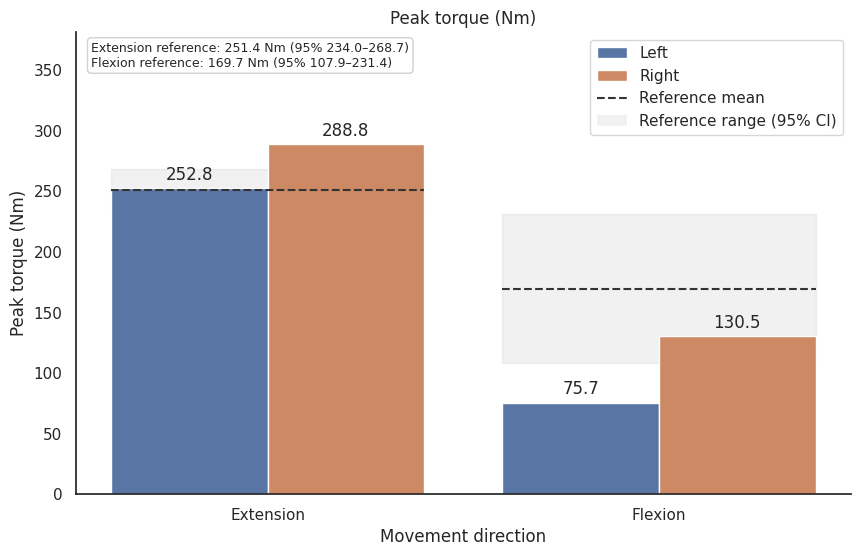

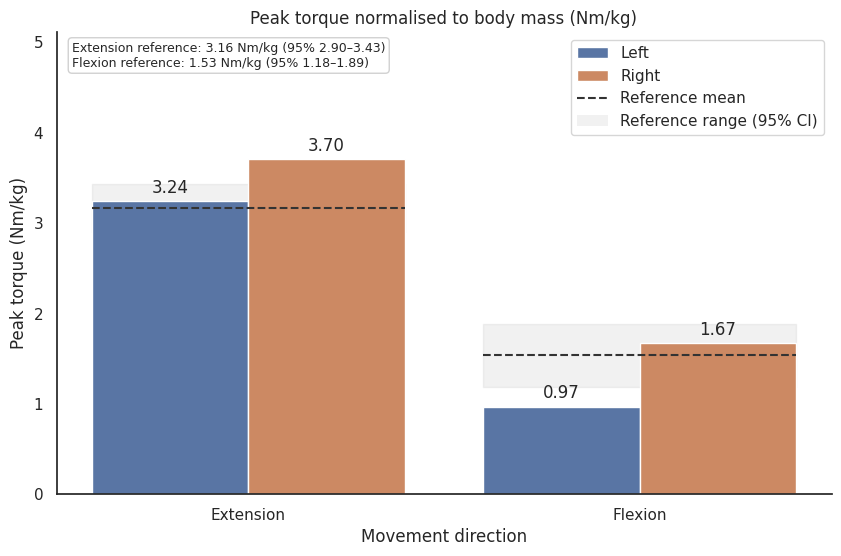

In [204]:
plot_peak_torque_with_reference(peaks_corrected, reference_selection)

## 8) Calculate the H:Q ratio

The hamstring-to-quadriceps ratio is calculated within the same limb:

$$
H:Q = \frac{T_{\mathrm{flexion}}}{T_{\mathrm{extension}}}
$$

where \(T\) is the peak torque normalised to body mass Nm/kg

In [205]:
calculate_hq_ratio(peaks_corrected)

direction,limb,extension,flexion,hq_ratio
0,left,3.24,0.97,0.30
1,right,3.70,1.67,0.45


## 9) Calculate the Limb Symmetry Index (LSI)

The Limb Symmetry Index compares the affected limb to the contralateral limb:

$$
LSI(\%) = 100 \times \frac{T_{\mathrm{affected}}}{T_{\mathrm{contralateral}}}
$$

In [206]:
calculate_lsi_table(peaks_corrected, affected_limb)

,direction,affected_limb,contralateral_limb,LSI (%)
0,extension,left,right,87.5
1,flexion,left,right,58.0


## 10) Convert the force-time data into long format

This conversion happens in the background.  
For teaching purposes, the notebook shows the first 10 rows of the converted table.

In [207]:
ft_long = build_force_time_long_from_case(case, peaks_corrected)

In [208]:
make_force_time_preview(ft_long, n=10)

,time_ms,movement,limb,direction,torque_nm,torque_nmkg
0,0,Left Extension,left,extension,1.6,0.02
1,20,Left Extension,left,extension,1.6,0.02
2,40,Left Extension,left,extension,1.9,0.02
3,60,Left Extension,left,extension,1.6,0.02
4,80,Left Extension,left,extension,1.2,0.02
5,100,Left Extension,left,extension,2.2,0.03
6,120,Left Extension,left,extension,1.9,0.02
7,140,Left Extension,left,extension,2.2,0.03
8,160,Left Extension,left,extension,1.2,0.02
9,180,Left Extension,left,extension,1.9,0.02


## 11) Plot the torque-time curves

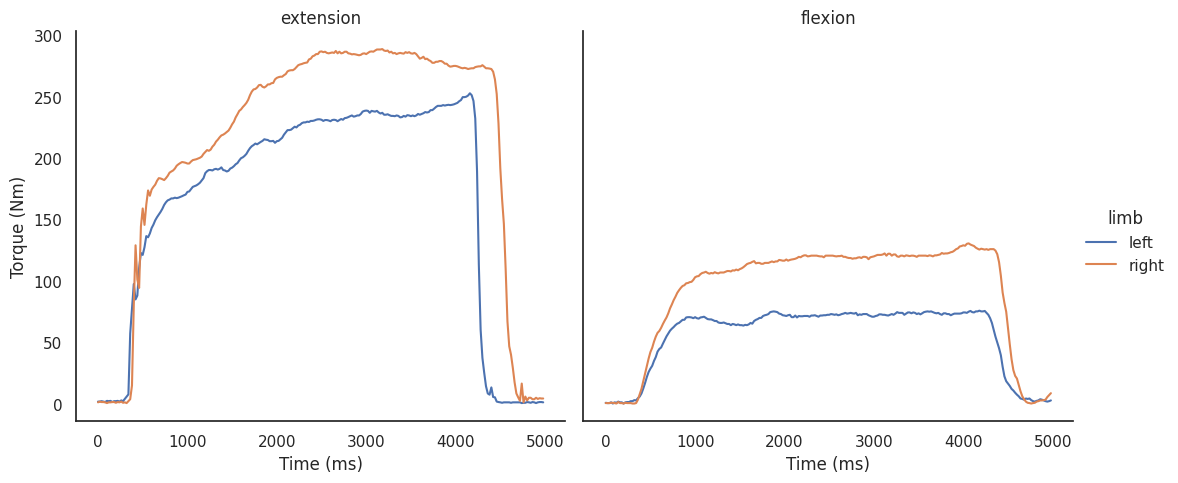

In [209]:
plot_force_time_curves(ft_long)

## 12) Align the curves to contraction onset

Different curves may begin to rise at slightly different times.  
To compare the early phase fairly, the time axis is aligned to a common contraction onset.

### How the alignment was done
For each movement curve, contraction onset was defined as the first time point at which torque exceeded **5% of that curve's peak value** for at least **3 consecutive samples**.

Because the sampling interval is 20 ms, this means that the signal had to remain above the threshold for at least:

$$
3 \times 20\ \mathrm{ms} = 60\ \mathrm{ms}
$$

After the onset was detected, the time axis was shifted so that the onset occurred at:

$$
t = 0\ \mathrm{ms}
$$

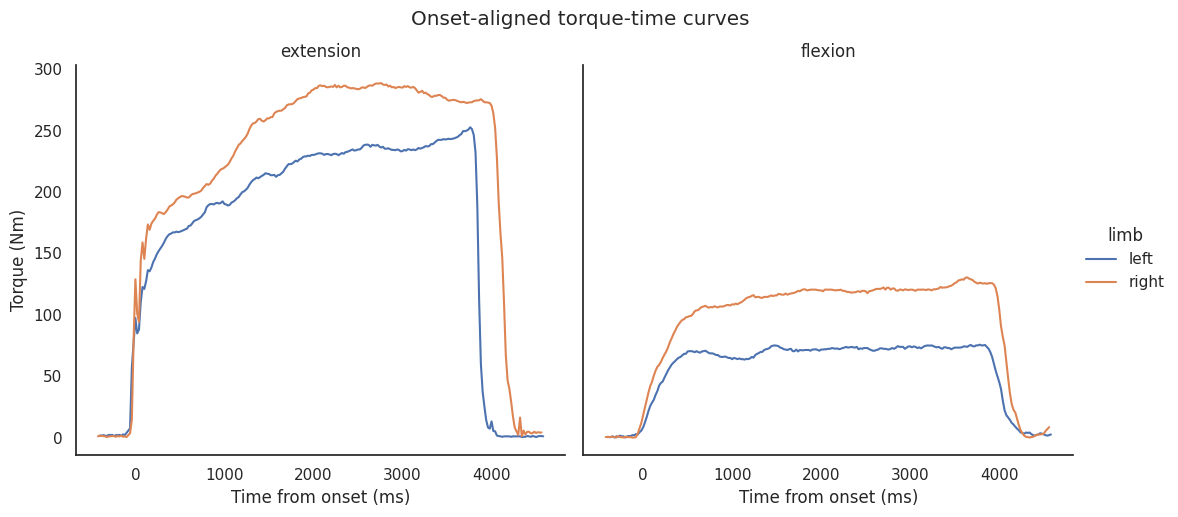

In [210]:
ft_aligned = align_to_onset(ft_long, value_col="torque_nm", pct=0.05, min_consecutive=3)
plot_force_time_curves(ft_aligned, aligned=True, title="Onset-aligned torque-time curves")

## 13) Calculate RFD100

This notebook reports only interval-based RFD values.  
Instantaneous RFD is intentionally left out here because the available sampling interval is 20 ms.

In [211]:
rfd_summary = build_rfd_summary(ft_aligned)
show_rfd_summary(rfd_summary)

,movement,torque_nm_rfd_100ms,torque_nm_rfd_200ms,torque_nmkg_rfd_100ms,torque_nmkg_rfd_200ms,limb,direction
0,Left Extension,237.4,228.3,3.04,2.93,left,extension
1,Left Flexion,202.4,181.3,2.60,2.32,left,flexion
2,Right Extension,166.3,238.0,2.13,3.05,right,extension
3,Right Flexion,272.3,217.5,3.49,2.79,right,flexion


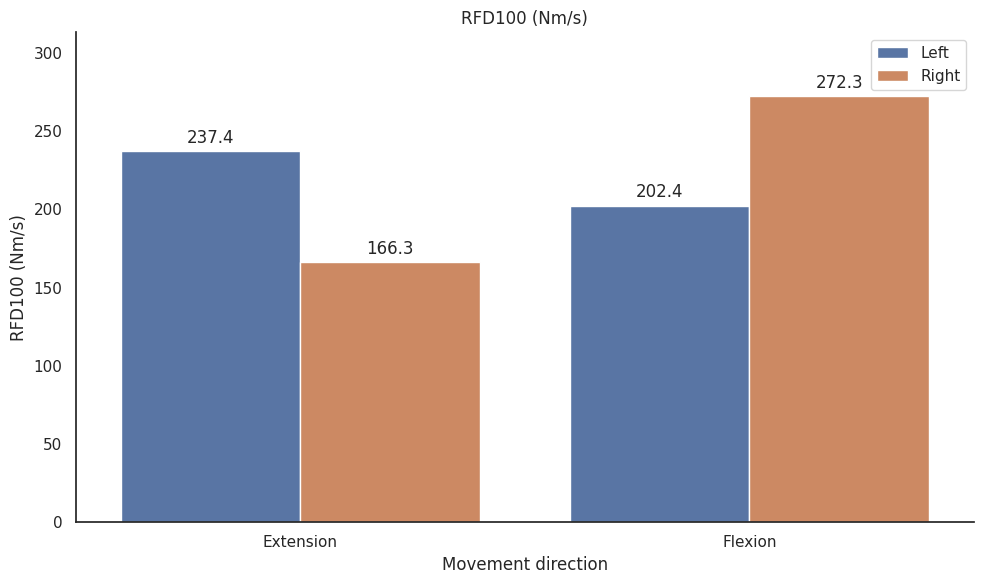

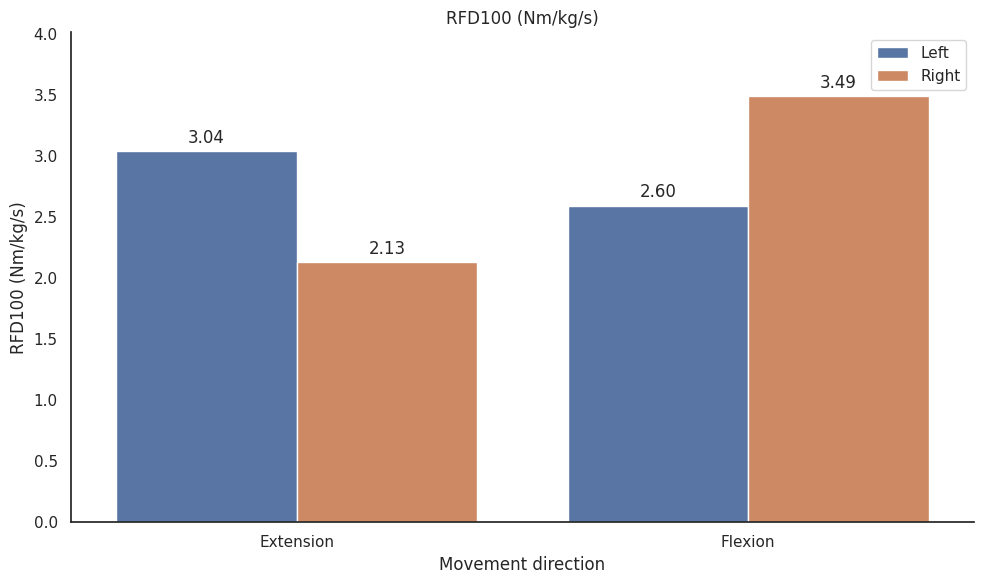

In [212]:
plot_rfd_bars(rfd_summary, interval_ms=100)

## 14) Plot RFD200

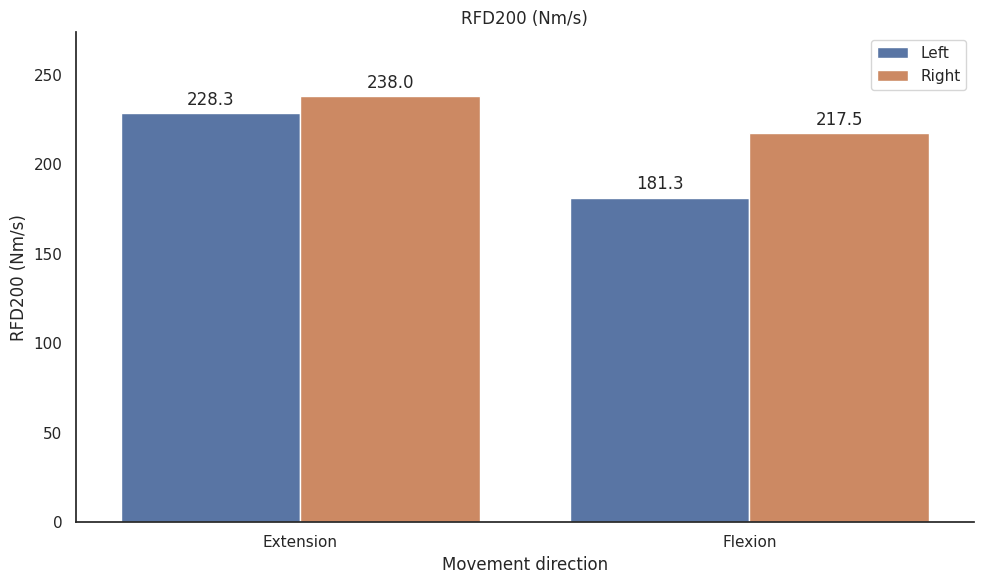

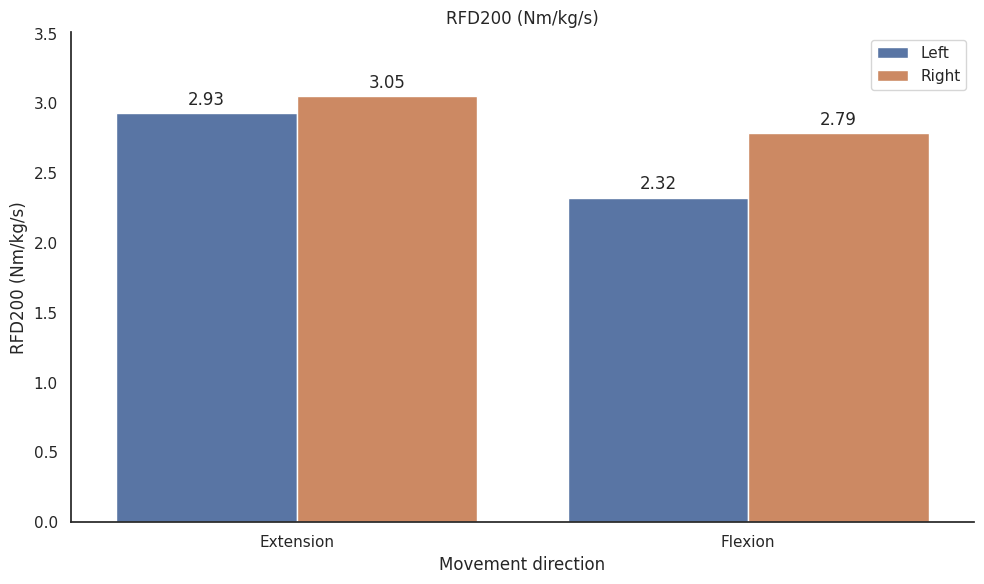

In [213]:
plot_rfd_bars(rfd_summary, interval_ms=200)

## 15) Final summary table

This table combines the main outcome variables used in interpretation.

In [214]:
build_final_summary(peaks_corrected, rfd_summary)

,limb,direction,torque_nm,torque_nmkg,torque_nm_rfd_100ms,torque_nm_rfd_200ms,torque_nmkg_rfd_100ms,torque_nmkg_rfd_200ms
0,left,extension,252.8,3.24,237.4,228.3,3.04,2.93
1,left,flexion,75.7,0.97,202.4,181.3,2.60,2.32
2,right,extension,288.8,3.70,166.3,238.0,2.13,3.05
3,right,flexion,130.5,1.67,272.3,217.5,3.49,2.79
